In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import vgg19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
import matplotlib.pyplot as plt
import time
from scipy.optimize import fmin_l_bfgs_b

In [2]:
def load_and_process_image(path, max_dim=512):
    """Load and preprocess an image for VGG19."""
    img = load_img(path)

    # Resize image while preserving aspect ratio
    long_dim = max(img.size)
    scale = max_dim / long_dim
    new_size = tuple([int(dim * scale) for dim in img.size])
    img = img.resize(new_size)

    # Convert to array and add batch dimension
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for VGG19
    img_array = vgg19.preprocess_input(img_array)

    return img_array

In [3]:
def deprocess_image(processed_img):
    """Convert processed image back to displayable format."""
    x = processed_img.copy()

    # Remove batch dimension
    if len(x.shape) == 4:
        x = np.squeeze(x, axis=0)

    # Undo VGG preprocessing
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]  # Convert BGR to RGB

    # Clip to valid range
    x = np.clip(x, 0, 255).astype('uint8')

    return x

In [4]:
def get_feature_representations(model, content_path, style_path, max_dim=512):
    """Extract content and style features from VGG19."""
    content_image = load_and_process_image(content_path, max_dim)
    style_image = load_and_process_image(style_path, max_dim)

    # Get feature representations
    content_outputs = model(content_image)
    style_outputs = model(style_image)

    # Extract content and style features
    content_features = [content_outputs[name] for name in content_layer_names]
    style_features = [style_outputs[name] for name in style_layer_names]

    return content_features, style_features, content_image

In [5]:
def gram_matrix(input_tensor):
    """Calculate Gram matrix for style representation."""
    # Reshape the tensor
    channels = int(input_tensor.shape[-1])
    a = tf.reshape(input_tensor, [-1, channels])

    # Calculate gram matrix: G = F^T * F
    n = tf.shape(a)[0]
    gram = tf.matmul(a, a, transpose_a=True)

    # Normalize the values
    gram = gram / tf.cast(n, tf.float32)

    return gram

In [6]:
def compute_content_loss(content_features, target_features):
    """Compute content loss as per the paper."""
    return tf.reduce_sum(tf.square(content_features - target_features))

In [7]:
def compute_style_loss(style_features, target_features):
    """Compute style loss as per the paper."""
    target_gram = gram_matrix(target_features)
    style_gram = gram_matrix(style_features)

    N_l, M_l = target_features.shape[-1], target_features.shape[1]*target_features.shape[2]
    M_l = np.max([M_l, 1e-9]) # making sure it's not zero
    E_l = 1/(4*(N_l**2)*(M_l**2)) * tf.reduce_sum(tf.square(style_gram - target_gram))

    return tf.reduce_sum(tf.square(style_gram - target_gram))

In [8]:
def compute_total_loss(content_features, style_features, target_features, style_weight=1e6, content_weight=1):
    """Compute the total loss - content and style."""
    style_score = 0
    content_score = 0

    # Content loss from the content layer
    content_score += compute_content_loss(
        target_features[content_layer_names[0]],
        content_features[0]
    )

    # Style loss from all style layers
    weight_per_style_layer = 1.0 / float(len(style_layer_names))
    for target_style, source_style in zip(
        [target_features[name] for name in style_layer_names],
        style_features
    ):
        style_score += weight_per_style_layer * compute_style_loss(source_style, target_style)

    # Weight the style and content loss
    style_score *= style_weight
    content_score *= content_weight

    # Total loss
    total_loss = style_score + content_score

    return total_loss, style_score, content_score

In [10]:
@tf.function()
def train_step(image, content_features, style_features, optimizer,
               content_weight=1, style_weight=1e6):
    """Perform one optimization step."""
    with tf.GradientTape() as tape:
        # Calculate features of current generated image
        outputs = model(image)
        target_features = {name: outputs[name] for name in outputs.keys()}

        # Compute loss
        loss, style_score, content_score = compute_total_loss(
            content_features, style_features, target_features,
            style_weight, content_weight
        )

    # Compute gradients
    grad = tape.gradient(loss, image)

    # Apply gradients
    optimizer.apply_gradients([(grad, image)])

    # Clip pixel values to valid range
    image.assign(tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=255.0))

    return loss, style_score, content_score

In [11]:
def run_style_transfer(content_path, style_path,
                       content_weight=1, style_weight=1e6,
                       iterations=1000, max_dim=512):
    """Run the style transfer algorithm."""
    # Get feature representations
    content_features, style_features, content_image = get_feature_representations(
        model, content_path, style_path, max_dim
    )

    # Initialize the generated image from the content image
    generated_image = tf.Variable(content_image, dtype=tf.float32)
    #generated_image = tf.Variable(tf.random.normal(content_image.shape,
    #                  mean=0.0, stddev=1.0,
    #                  dtype=tf.float32))

    # Create optimizer (Adam as recommended in the paper)
    optimizer = tf.optimizers.Adam(learning_rate=5.0)

    # Initialize progress tracking
    start_time = time.time()
    step = 0

    # Track best results
    best_loss, best_img = float('inf'), None

    # Optimization loop
    for step in range(iterations):
        loss, style_score, content_score = train_step(
            generated_image, content_features, style_features,
            optimizer, content_weight, style_weight
        )

        if loss < best_loss:
            best_loss = loss
            best_img = generated_image.numpy()

        # Print progress
        if step % 100 == 0:
            print(f"Iteration: {step}")
            print(f"Total loss: {loss:.4e}, "
                  f"Style loss: {style_score:.4e}, "
                  f"Content loss: {content_score:.4e}")
            print(f"Time elapsed: {time.time() - start_time:.2f}s")

    # Return the best image
    return deprocess_image(best_img)

In [9]:
@tf.function
def compute_loss(model, image, content_features, style_features):
    """Compute the total loss."""
    with tf.GradientTape() as tape:
        tape.watch(image)

        # Get features of current image
        outputs = model(image)

        '''

        # Content loss
        content_loss = tf.add_n([
            get_content_loss(content_features[name], outputs[name])
            for name in CONTENT_LAYERS
        ])
        content_loss *= CONTENT_WEIGHT

        # Style loss
        style_loss = tf.add_n([
            get_style_loss(style_features[name], gram_matrix(outputs[name]))
            for name in STYLE_LAYERS
        ])
        style_loss *= STYLE_WEIGHT

        # Total loss
        total_loss = content_loss + style_loss
        '''
        target_features = {name: outputs[name] for name in outputs.keys()}

        # Compute loss
        loss, style_score, content_score = compute_total_loss(
            content_features, style_features, target_features,
            style_weight = 1e6, content_weight = 1
        )

    # Get gradients
    grads = tape.gradient(loss, image)

    return loss, grads

class Evaluator:
    """Class for L-BFGS optimization."""
    def __init__(self, model, content_features, style_features, img_shape):
        self.model = model
        self.content_features = content_features
        self.style_features = style_features
        self.shape = img_shape

    def loss(self, x):
        """Calculate loss and gradient for L-BFGS."""
        img = x.reshape(self.shape)
        img = tf.convert_to_tensor(img, dtype=tf.float32)

        # Compute loss and gradients
        loss, grad = compute_loss(self.model, img, self.content_features, self.style_features)

        # Convert to numpy for L-BFGS
        loss_value = loss.numpy().astype(np.float64)
        grad_values = grad.numpy().flatten().astype(np.float64)

        return loss_value, grad_values

    def f(self, x):
        """Function value only for L-BFGS."""
        loss_value, _ = self.loss(x)
        return loss_value

    def g(self, x):
        """Gradient value only for L-BFGS."""
        _, grad_values = self.loss(x)
        return grad_values

In [10]:
def run_style_transfer(content_path, style_path):
    ITERATIONS = 1000
    """Run the style transfer algorithm."""

    print("Loading images and extracting features...")
    content_features, style_features, content_image = get_feature_representations(
        model, content_path, style_path
    )

    # Initialize with the content image
    initial_image = content_image.astype(np.float64)
    img_shape = initial_image.shape
    initial_x = initial_image.flatten()

    # Create evaluator
    evaluator = Evaluator(model, content_features, style_features, img_shape)

    # Optimize with L-BFGS
    print(f"Starting optimization with L-BFGS for {ITERATIONS} iterations...")
    start_time = time.time()

    best_loss = float('inf')
    best_img = None

    # Main optimization loop
    for i in range(ITERATIONS):
        print(f"Iteration {i+1}/{ITERATIONS}")
        iteration_start = time.time()

        # Run L-BFGS optimization
        x, min_val, info = fmin_l_bfgs_b(
            evaluator.f,
            initial_x,
            fprime=evaluator.g,
            maxfun=20,  # Number of function evaluations per iteration
            maxiter=1   # Just one outer iteration at a time
        )

        print(f"Loss: {min_val}")
        print(f"Time for iteration {i+1}: {time.time() - iteration_start:.2f}s")

        # Track best result
        if min_val < best_loss:
            best_loss = min_val
            best_img = x.reshape(img_shape)

        # Update initial point for next iteration
        initial_x = x

    # Return the best result
    final_img = best_img if best_img is not None else x.reshape(img_shape)
    final_img = deprocess_image(final_img)

    print(f"Total time: {time.time() - start_time:.2f}s")

    return final_img

In [11]:
# Define content and style layers according to the paper
content_layer_names = ['block4_conv2']
style_layer_names = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

# Load VGG19 model
vgg = vgg19.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

In [12]:
# Create intermediate model that outputs layer activations
outputs = {}
for name in content_layer_names + style_layer_names:
    outputs[name] = vgg.get_layer(name).output
model = tf.keras.Model(vgg.input, outputs)

In [37]:
# replace max pooling with average pooling
output_dict = {}
input_layer, *layers = vgg.layers
x = input_layer.output
output_dict[input_layer.name] = x

for layer in layers:
    if isinstance(layer, keras.layers.MaxPooling2D):
        layer = keras.layers.AveragePooling2D(
                pool_size=layer.pool_size,
                strides=layer.strides,
                padding=layer.padding,
                data_format=layer.data_format,
                name=f"{layer.name}_avg"
        )

    x=layer(x)
    output_dict[layer.name] = x

model = tf.keras.Model(vgg.input, output_dict)

In [13]:
content_path = "drive/MyDrive/Master's/Second Year Grad/CV/CV Final Project/code/dataset/portrait.jpg"  # Replace with your content image path
style_path = "drive/MyDrive/Master's/Second Year Grad/CV/CV Final Project/code/dataset/wave.jpg"      # Replace with your style image path

In [14]:
# Run style transfer
result_image = run_style_transfer(
    content_path=content_path,
    style_path=style_path,
    #content_weight=1,       # Balance between content and style
    #style_weight=1e6,       # Higher values prioritize style
    #iterations=1000,        # More iterations = better results but slower
    #max_dim=512            # Maximum dimension of input images
)

Loading images and extracting features...
Starting optimization with L-BFGS for 1000 iterations...
Iteration 1/1000
Loss: 6.515268634824256e+21
Time for iteration 1: 3.44s
Iteration 2/1000
Loss: 5.97935885651563e+21
Time for iteration 2: 0.78s
Iteration 3/1000
Loss: 5.469631880540629e+21
Time for iteration 3: 0.78s
Iteration 4/1000
Loss: 4.990509115833424e+21
Time for iteration 4: 0.78s
Iteration 5/1000
Loss: 4.547916736553682e+21
Time for iteration 5: 0.77s
Iteration 6/1000
Loss: 4.143521356038506e+21
Time for iteration 6: 0.79s
Iteration 7/1000
Loss: 3.770666935513619e+21
Time for iteration 7: 0.78s
Iteration 8/1000
Loss: 3.427836887804504e+21
Time for iteration 8: 0.78s
Iteration 9/1000
Loss: 3.11668459692436e+21
Time for iteration 9: 0.77s
Iteration 10/1000
Loss: 2.8371684045766336e+21
Time for iteration 10: 0.78s
Iteration 11/1000
Loss: 2.5834378533703936e+21
Time for iteration 11: 0.78s
Iteration 12/1000
Loss: 2.3594451334536343e+21
Time for iteration 12: 0.78s
Iteration 13/1000


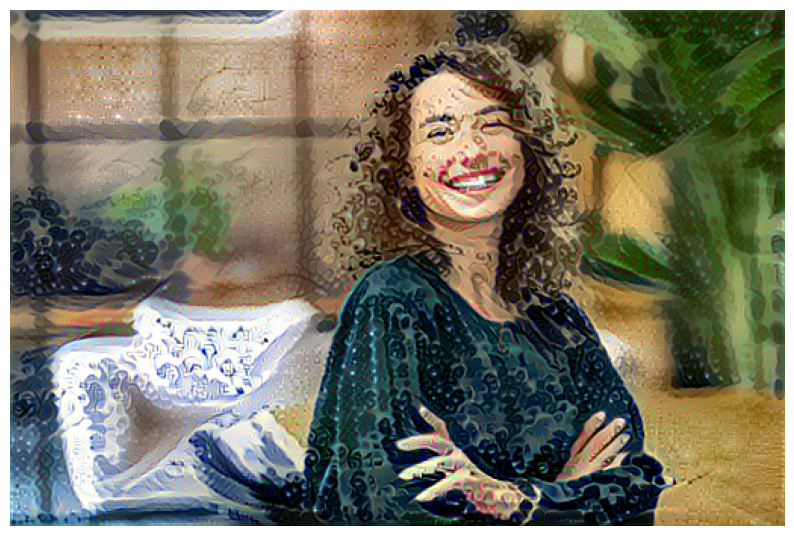

In [15]:
# Display result NEW
plt.figure(figsize=(10, 10))
plt.imshow(result_image)
plt.axis('off')
plt.show()

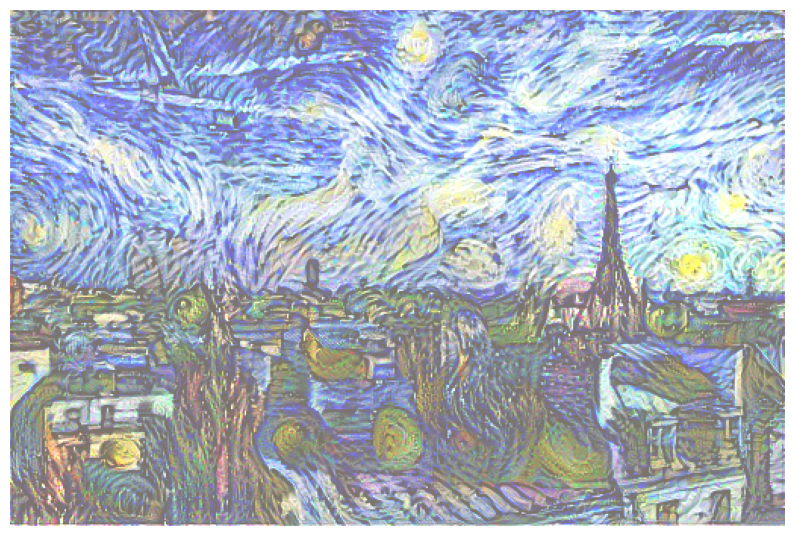

In [16]:
# Display result ORIGINAL
plt.figure(figsize=(10, 10))
plt.imshow(result_image)
plt.axis('off')
plt.show()

In [ ]:
# Save result
array_to_img(result_image).save("drive/MyDrive/Intro CV/Final Project/CV Final Project/code/result/portrait_wave.jpg")
print("Style transfer complete! Image saved.")

Style transfer complete! Image saved.
